In [1]:
import torch
from transformers import BertModel, BertTokenizer
import matplotlib.pyplot as plt
import numpy as np
from torch.nn.functional import cosine_similarity

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4949.63it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can

Ready!


In [2]:
def get_bert_embedding(word):
    inputs = bert_tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)

# Words jo axes define karte hain
word_pairs = {
    "Gender":  ("man", "woman"),
    "Royal":   ("king", "queen"),
    "Animal":  ("dog", "cat"),
    "Feeling": ("happy", "sad"),
    "Size":    ("big", "small"),
}

# Saare words ke embeddings
all_words = []
for pair in word_pairs.values():
    all_words.extend(pair)

embeddings = {word: get_bert_embedding(word) for word in all_words}
print("Embeddings ready!")
print(f"Words: {all_words}")

Embeddings ready!
Words: ['man', 'woman', 'king', 'queen', 'dog', 'cat', 'happy', 'sad', 'big', 'small']


In [3]:

# Axis = word2 - word1
axes = {}
for axis_name, (word1, word2) in word_pairs.items():
    axes[axis_name] = embeddings[word2] - embeddings[word1]
    print(f"{axis_name} axis: {word1} → {word2}, magnitude: {axes[axis_name].norm():.2f}")

Gender axis: man → woman, magnitude: 3.46
Royal axis: king → queen, magnitude: 3.08
Animal axis: dog → cat, magnitude: 3.72
Feeling axis: happy → sad, magnitude: 3.85
Size axis: big → small, magnitude: 3.93


In [4]:
# king - man + woman = ?
result = embeddings["king"] - embeddings["man"] + embeddings["woman"]


similarities = {}
for word, emb in embeddings.items():
    similarities[word] = cosine_similarity(
        result.unsqueeze(0),
        emb.unsqueeze(0)
    ).item()


sorted_sim = sorted(similarities.items(), 
                    key=lambda x: x[1], reverse=True)

print("king - man + woman = ?")
print("\nTop similar words:")
for word, sim in sorted_sim:
    print(f"  {word:8}: {sim:.4f}")

king - man + woman = ?

Top similar words:
  king    : 0.9248
  queen   : 0.8644
  woman   : 0.8611
  dog     : 0.7978
  cat     : 0.7944
  sad     : 0.7909
  happy   : 0.7579
  small   : 0.7511
  big     : 0.7363
  man     : 0.6996


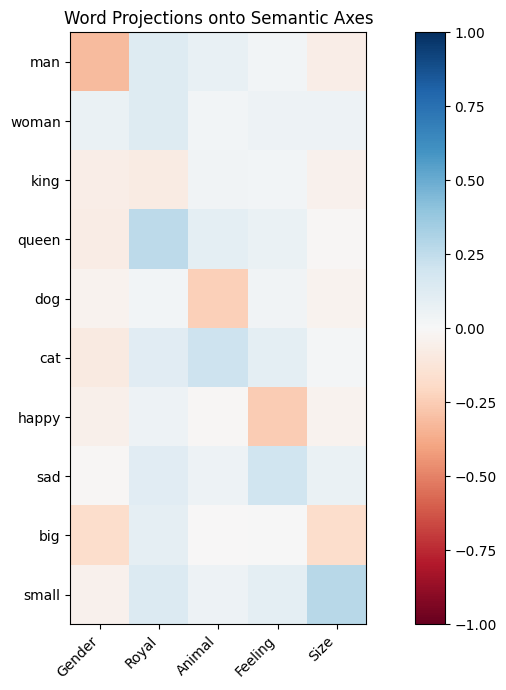

In [5]:

axis_names = list(word_pairs.keys())
word_list  = list(embeddings.keys())

projection_matrix = np.zeros((len(word_list), len(axis_names)))

for j, axis_name in enumerate(axis_names):
    axis_vec = axes[axis_name]
    for i, word in enumerate(word_list):
        
        proj = cosine_similarity(
            embeddings[word].unsqueeze(0),
            axis_vec.unsqueeze(0)
        ).item()
        projection_matrix[i, j] = proj

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(projection_matrix, cmap="RdBu", vmin=-1, vmax=1)

ax.set_xticks(range(len(axis_names)))
ax.set_yticks(range(len(word_list)))
ax.set_xticklabels(axis_names, rotation=45, ha="right")
ax.set_yticklabels(word_list)

plt.colorbar(im)
ax.set_title("Word Projections onto Semantic Axes")

plt.tight_layout()
plt.show()

* Embeddings contain **semantic directions**, meaning relationships are encoded as vector movements in space.

* A classic example of word analogy works:
  **king − man + woman ≈ queen**

* Each dimension (axis) in the embedding space represents a **different aspect of meaning**.

* BERT automatically **learns these semantic directions during training**, without explicit programming.
